Text(0.5, 1.0, 'Max')

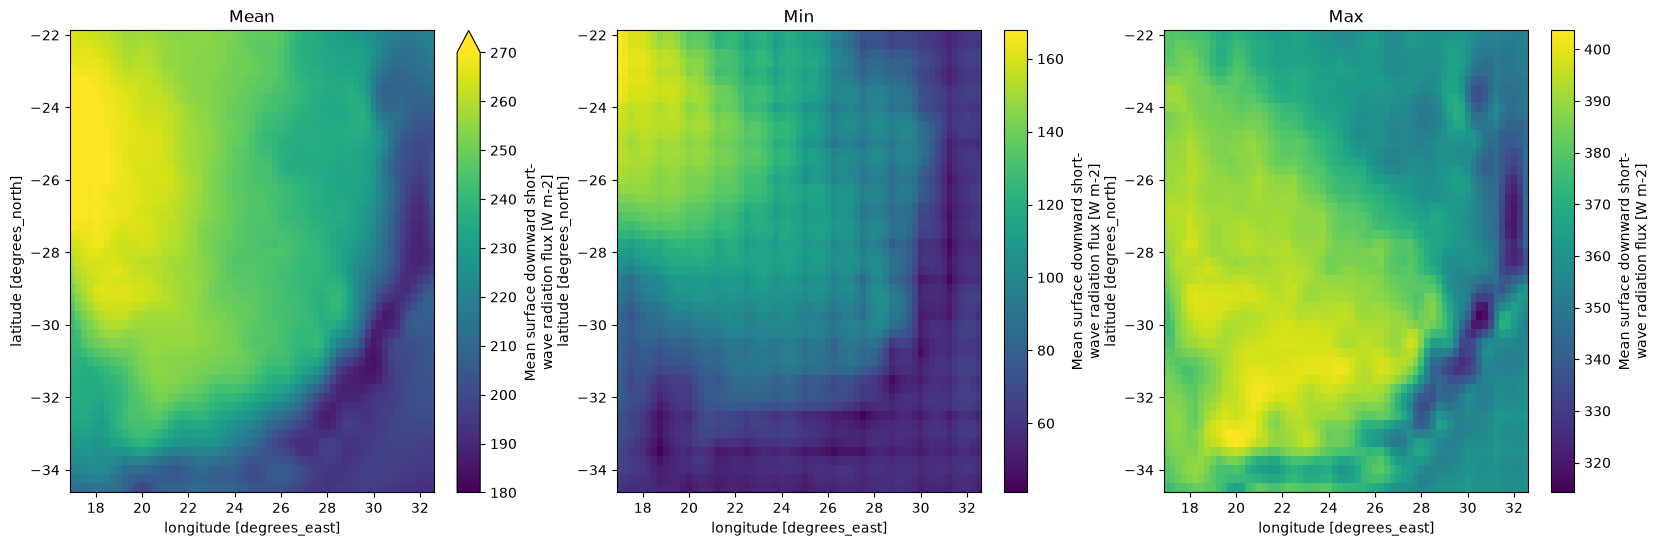

In [68]:
import matplotlib.pyplot as plt
from srm.utils import open_icechunk
import icechunk
import xarray as xr

path_output = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.12.0"

var = "rsds"
ssp_ens = "008"
g6_ens = "003"
hist_ens = "r3i1p1f1"

ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="ssp245/" + var + "/" + ssp_ens,
)[var]

ssp_subset=ssp.sel(lat=slice(-34.5,-22),lon=slice(17,32.5))

ssp_coarse = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]
ssp_coarse_subset=ssp_coarse.sel(lat=slice(-34.5,-22),lon=slice(17,32.5))

storage = icechunk.s3_storage(
    bucket="carbonplan-share",
    prefix="nasa-nex-virtual/nasa-nex-gddp-cmip6.icechunk",
    from_env=True,
)

authorize = icechunk.containers_credentials(
    {"s3://nex-gddp-cmip6/": icechunk.s3_anonymous_credentials()}
)

repo = icechunk.Repository.open(
    storage,
    authorize_virtual_chunk_access=authorize,
)
session = repo.readonly_session("main")
# note: if you don't have cftime in your deps, you might need to pass decode_times=False.
dt = xr.open_datatree(session.store, engine="zarr", consolidated=False)

NEX_subset = dt['CESM2-WACCM']['ssp245']['rsds'].sel(lat=slice(-34.5,-22),lon=slice(17,32.5)).load()


plt.figure(figsize=(20,13))
plt.subplot(2,3,1)
ssp_subset.mean(dim='time').plot()
plt.title('This data, Mean')

plt.subplot(2,3,2)
ssp_subset.quantile(0.01,dim='time').plot()
plt.title('This data, 1st percentile')

plt.subplot(2,3,3)
ssp_subset.quantile(0.99,dim='time').plot()
plt.title('This data, 99th percentile')

plt.subplot(2,3,4)
NEX_subset.mean(dim='time').plot()
plt.title('NEX data, Mean')

plt.subplot(2,3,5)
NEX_subset.quantile(0.01,dim='time').plot()
plt.title('NEX data, 1st percentile')

plt.subplot(2,3,6)
NEX_subset.quantile(0.99,dim='time').plot()
plt.title('NEX data, 99th percentile')

plt.tight_layout()

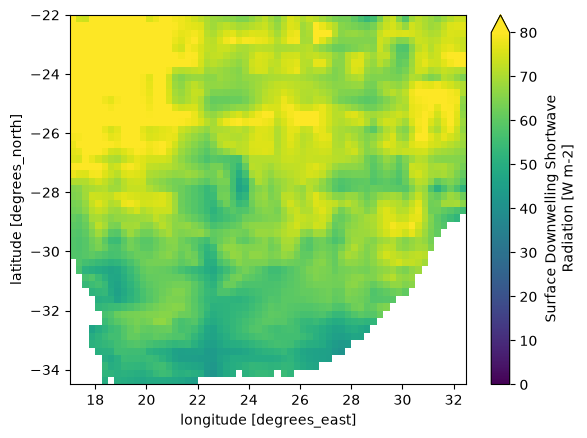

In [105]:
NEX_subset.min(dim='time').plot(vmin=0, vmax=80)

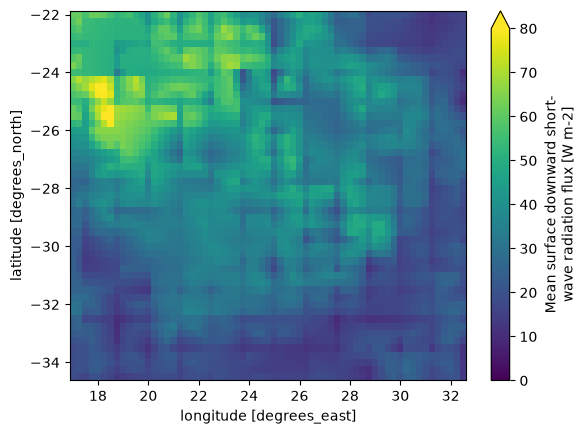

In [106]:
ssp_subset.min(dim='time').plot(vmin=0, vmax=80)

In [98]:
NEX_subset.min(dim='time').min().values

array(41.413937, dtype=float32)

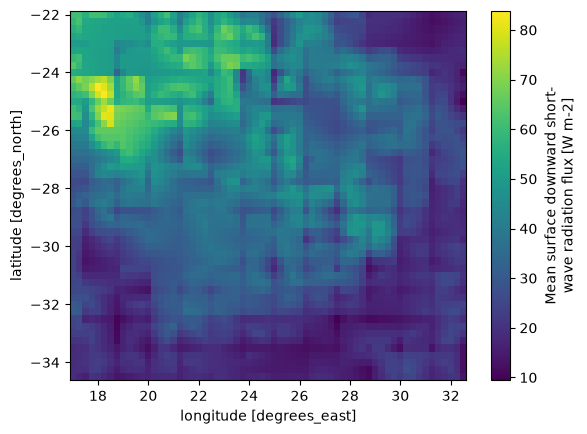

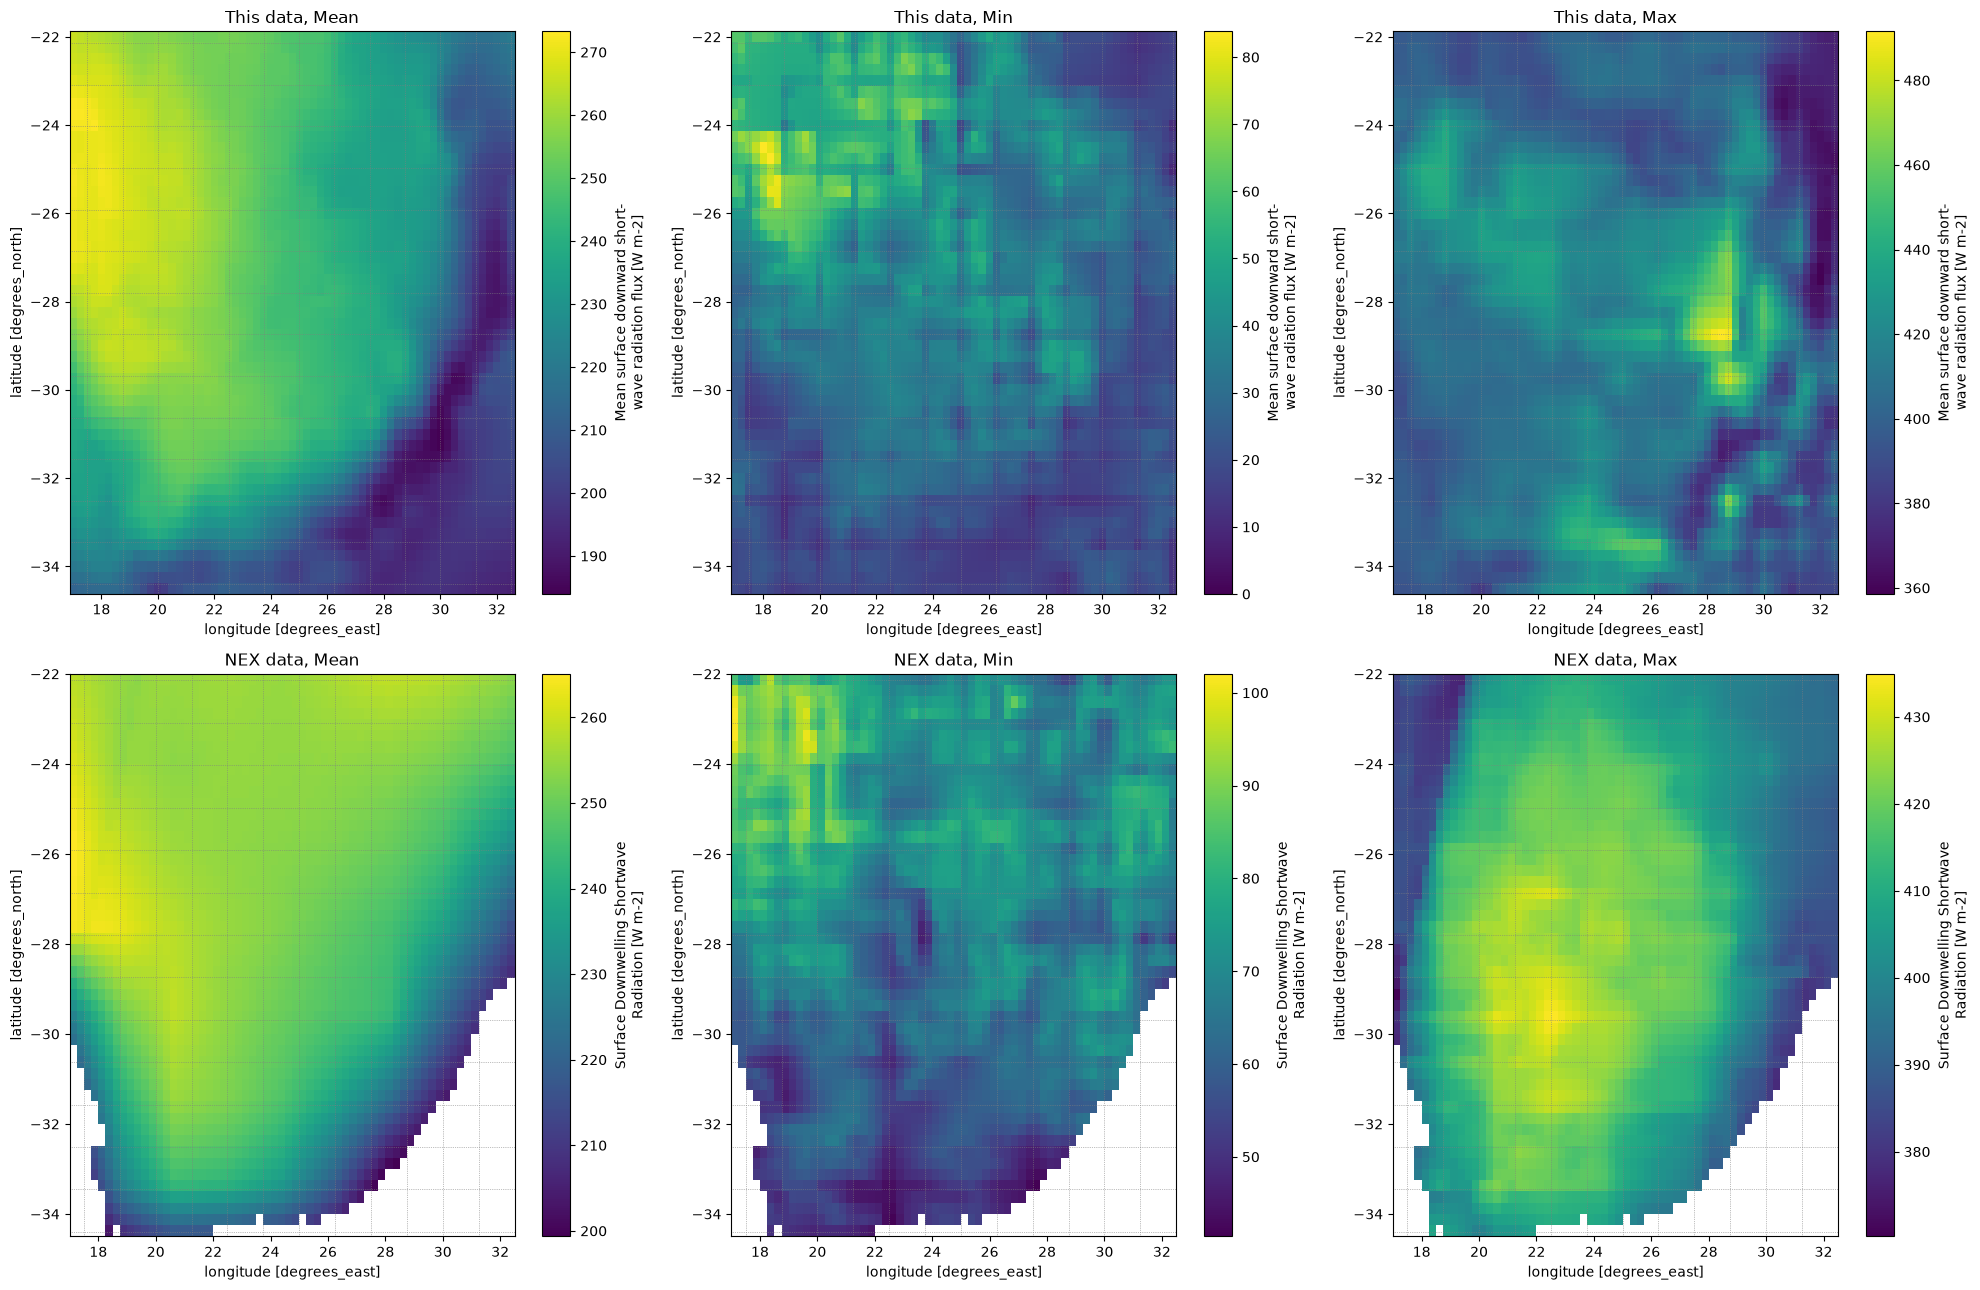

In [108]:
plt.figure(figsize=(20,13))
plt.subplot(2,3,1)
ssp_subset.mean(dim='time').plot()
plt.title('This data, Mean')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.subplot(2,3,2)
ssp_subset.min(dim='time').plot(vmin=0)
plt.title('This data, Min')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.subplot(2,3,3)
ssp_subset.max(dim='time').plot()
plt.title('This data, Max')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.subplot(2,3,4)
NEX_subset.mean(dim='time').plot()
plt.title('NEX data, Mean')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.subplot(2,3,5)
NEX_subset.min(dim='time').plot()
plt.title('NEX data, Min')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.subplot(2,3,6)
NEX_subset.max(dim='time').plot()
plt.title('NEX data, Max')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray',linewidth=0.5)
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray',linewidth=0.5)

plt.tight_layout()

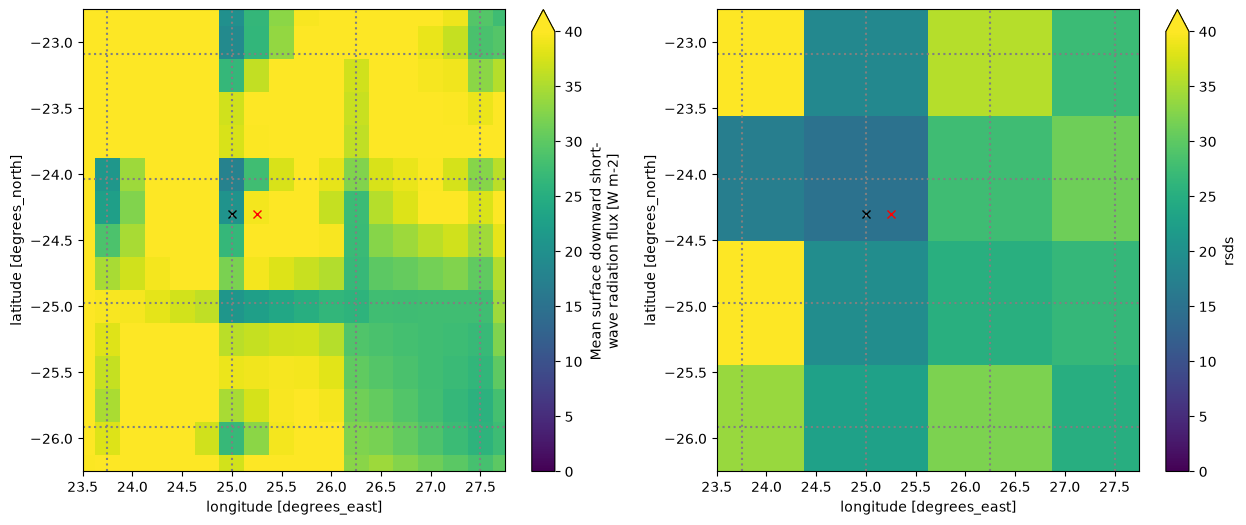

In [91]:
ylims=[-25.25-1,-23.75+1]
xlims=[24.5-1,26.75+1]
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
ssp_subset.min(dim='time').plot(vmin=0, vmax=40)
plt.ylim(ylims)
plt.xlim(xlims)
plt.plot([25],[-24.3],'xk')
plt.plot([25.25],[-24.3],'xr')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray')
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray')

plt.subplot(1,2,2)
ssp_coarse.min(dim='time').plot(vmin=0, vmax=40)
plt.ylim(ylims)
plt.xlim(xlims)
plt.plot([25],[-24.3],'xk')
plt.plot([25.25],[-24.3],'xr')
for lat in ssp_coarse_subset.lat:
    plt.axhline(y=lat,linestyle=':',color='gray')
for lon in ssp_coarse_subset.lon:
    plt.axvline(x=lon,linestyle=':',color='gray')

In [ ]:
A little more detail here. 

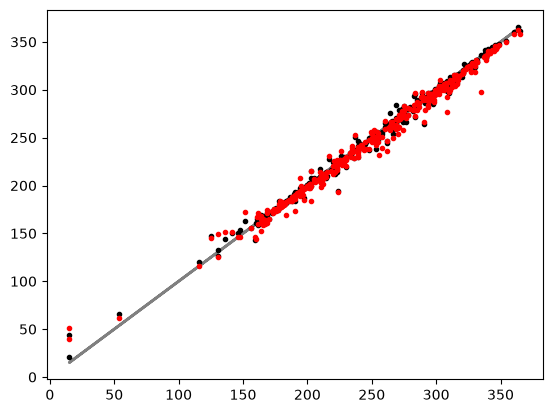

In [65]:
plt.plot(ssp_coarse.sel(lat=-24.3,lon=25.25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),
         ssp_coarse.sel(lat=-24.3,lon=25.25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),'-',color='gray',linewidth=2)

plt.plot(ssp_coarse.sel(lat=-24.3,lon=25.25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),
    ssp_subset.sel(lat=-24.3,lon=25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),'.k')

plt.plot(ssp_coarse.sel(lat=-24.3,lon=25.25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),
         ssp_subset.sel(lat=-24.3,lon=25.25,method='nearest').sel(time=slice("2063-01-01","2064-01-01")),'.',color='red')

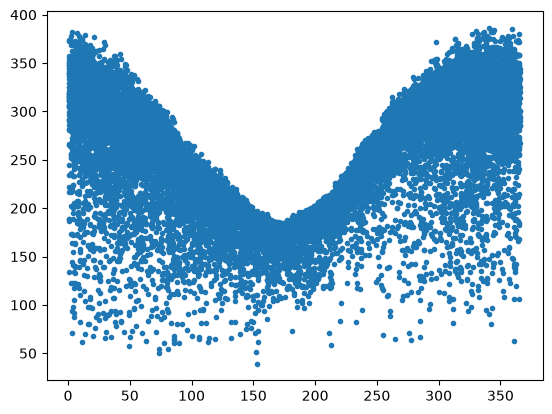

In [21]:
coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

In [22]:
coarse_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [23]:
# Coarse debiased data



coarse_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/historical/" + var + "/" + hist_ens,
)[var]



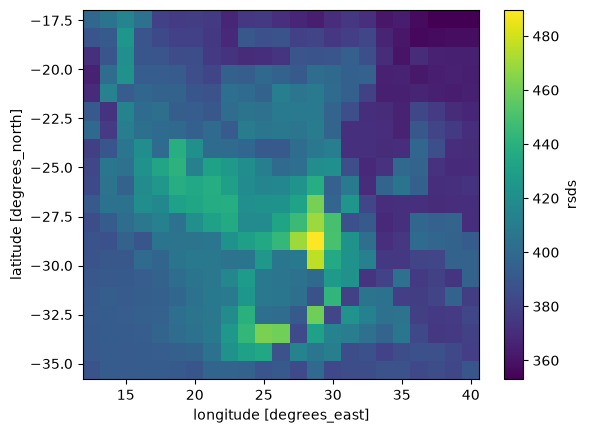

In [29]:
ds_subset.max(dim='time').plot()

In [30]:
ds_subset.min(dim='time')

<xarray.DataArray 'rsds' (lat: 20, lon: 23)> Size: 2kB
dask.array<_nanmin_skip-aggregate, shape=(20, 23), dtype=float32, chunksize=(8, 16), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -35.34 -34.4 -33.46 ... -19.32 -18.38 -17.43
  * lon      (lon) float64 184B 12.5 13.75 15.0 16.25 ... 36.25 37.5 38.75 40.0